First few rows of the dataset:
   sepal length (cm)  sepal width (cm)  target
0                5.1               3.5       0
1                4.9               3.0       0
2                4.7               3.2       0
3                4.6               3.1       0
4                5.0               3.6       0
Iteration 0: Log Loss: 0.6931471805599434
Iteration 100: Log Loss: 0.16649171765680504
Iteration 200: Log Loss: 0.1097426588020068
Iteration 300: Log Loss: 0.08639173812468848
Iteration 400: Log Loss: 0.07307864825873527
Iteration 500: Log Loss: 0.0642470246641442
Iteration 600: Log Loss: 0.05785272374541091
Iteration 700: Log Loss: 0.05295257485297463
Iteration 800: Log Loss: 0.049045094362973995
Iteration 900: Log Loss: 0.04583627313343033

Accuracy: 100.00%


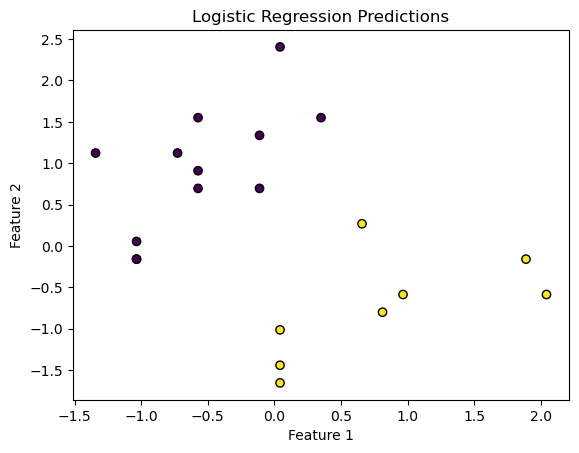

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Load the Dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# We will consider only two classes for binary classification
X = X[y != 2]  # Taking only class 0 and class 1
y = y[y != 2]

# Select only the first two features for easier visualization
X = X[:, :2]  # Use only the first two features

# Convert to a DataFrame for easier handling
df = pd.DataFrame(data=X, columns=iris.feature_names[:2])  # Use only the first two features
df['target'] = y

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())

# Step 2: Preprocess the Data
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 3: Implement Logistic Regression with Gradient Descent
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def log_loss(self, y_true, y_pred):
        return -np.mean(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            # Compute the gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update the weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Optionally, you can print the log loss every 100 iterations
            if _ % 100 == 0:
                loss = self.log_loss(y, y_pred)
                print(f'Iteration {_}: Log Loss: {loss}')

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        return np.round(y_pred)

# Step 4: Train the Logistic Regression Model
model = LogisticRegressionGD(learning_rate=0.1, n_iterations=1000)
model.fit(X_train, y_train)

# Step 5: Make Predictions
y_pred = model.predict(X_test)

# Step 6: Evaluate the Model
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

accuracy_score = accuracy(y_test, y_pred)
print(f'\nAccuracy: {accuracy_score * 100:.2f}%')

# Step 7: Visualize Predictions
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', edgecolor='k', marker='o')
plt.title('Logistic Regression Predictions')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
